In [1]:
import pathlib
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities_ES as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig3_sparseKO_place_fields')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [4]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for mouse in sparse_mice:
    for day in range(6):
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
               
                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']
                widths = shuff_results[mouse][chan][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25)  #* (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
              

                n_fields = np.bincount(rising_edges[mask,0])
                
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)
        

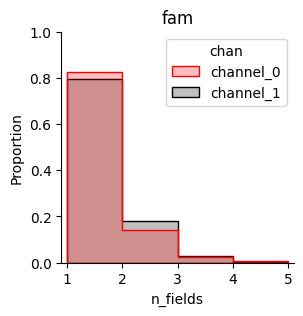

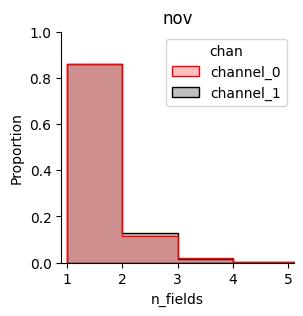

In [5]:
for nov in ('fam', 'nov'):

    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov,:], x='n_fields', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
                binwidth=1., fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    ax.set_ylim([0,1])
    ax.set_xlim([.9,5.1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    fig.savefig(figdir / f'n_fields_hist_{nov}.pdf', bbox_inches='tight')



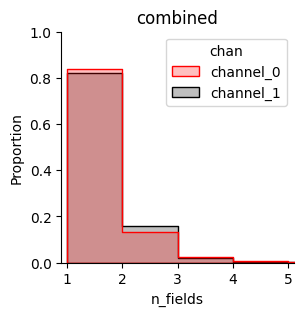

In [6]:
fig,ax = plt.subplots(figsize=[3,3])
sns.histplot(data=df, x='n_fields', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1., fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1])
ax.set_xlim([.9,5.1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')

fig.savefig(figdir / f'n_fields_hist_combined.pdf', bbox_inches='tight')

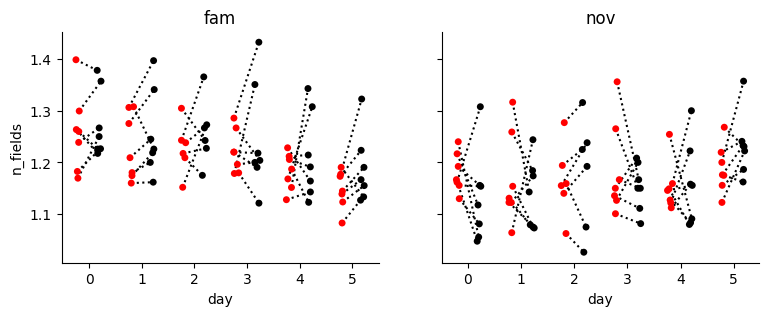

In [10]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)
    ax[i].set_title(nov)



    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    
fig.savefig( figdir / 'n_fields_per_day.pdf', bbox_inches='tight')

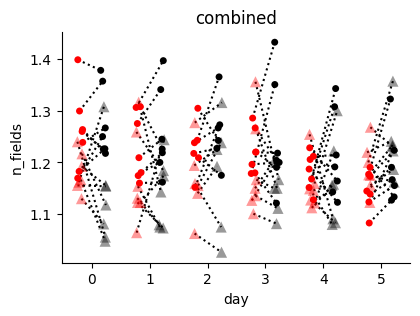

In [24]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey=True)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='n_fields',
            hue='chan', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)

# for d in range(0,12,2):
#     for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
#         ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='n_fields',
            hue='chan',
            hue_order=('channel_0', 'channel_1'),
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            marker='^',
            alpha=.4,
            s=8,
            legend=False)


ax.set_title(nov)



for d in range(0,24,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')
# ax.set_ylim([1,1.5])
    
fig.savefig( figdir / 'n_fields_per_day_combined.pdf', bbox_inches='tight')

In [16]:
ax.collections[d]

In [25]:
with open('/home/mplitt/shuffle_pkls/sparse_n_fields_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']

    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")


n_fields true coef = 0.019201472346692162, p = 0.293 
rank_n_fields true coef = 163.83694124090223, p = 0.122 


# field width comparison

In [26]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for mouse in sparse_mice:
    for day in range(6):
        
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']
                widths = shuff_results[mouse][chan][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25) * (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
                widths = widths[mask]

                for w in widths:
                   
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['width'].append(10*w)

df = pd.DataFrame.from_dict(df)

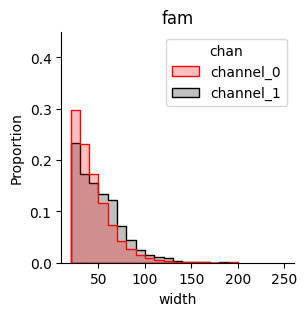

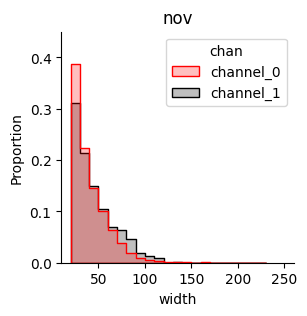

In [27]:

for nov in ('fam', 'nov'):
    fig,ax = plt.subplots(figsize=[3,3])

    sns.histplot(data=df.loc[df['nov']==nov,:], 
                 x='width', 
                 hue='chan', 
                 cumulative=False, 
                 hue_order=('channel_0', 'channel_1'), 
                 palette=['red', 'black'],
                 binwidth=10, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    
    ax.set_xlim([10,260])
    ax.set_ylim([0,.45])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    fig.savefig(figdir / f'field_widths_hist_{nov}.pdf', bbox_inches='tight')


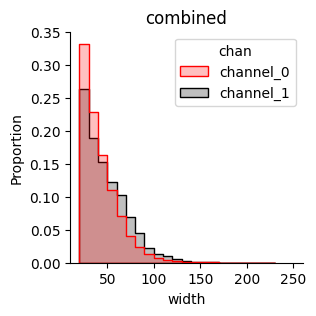

In [28]:

fig,ax = plt.subplots(figsize=[3,3])

sns.histplot(data=df, 
            x='width', 
            hue='chan', 
            cumulative=False, 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            binwidth=10, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)

ax.set_xlim([10,260])
ax.set_ylim([0,.35])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')

fig.savefig(figdir / f'field_widths_hist_combined.pdf', bbox_inches='tight')


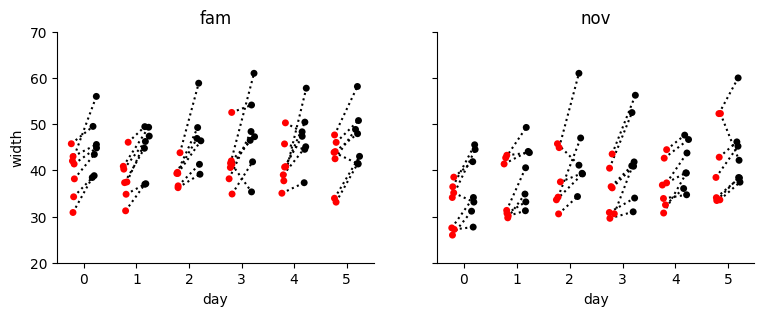

In [29]:
df_mu = df.groupby(['mouse','day','chan','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=.2,
                ax=ax[i],
                legend=False)
    ax[i].set_title(nov)
    ax[i].set_ylim([20,70])

    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'field_widths_per_day.pdf', bbox_inches='tight')

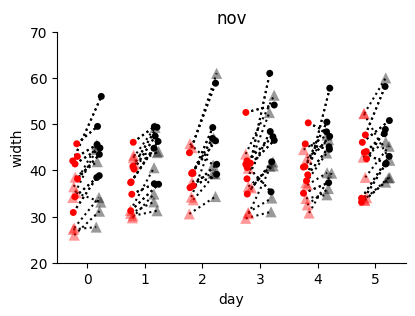

In [31]:
df_mu = df.groupby(['mouse','day','chan','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey=True)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='width',
            hue='chan', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)

# for d in range(0,12,2):
#     for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
#         ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='width',
            hue='chan',
            hue_order=('channel_0', 'channel_1'),
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            marker='^',
            alpha=.4,
            s=8,
            legend=False)


ax.set_title(nov)



for d in range(0,24,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


for d in range(0,12,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([20,70])

fig.savefig( figdir / 'field_widths_per_day_combined.pdf', bbox_inches='tight')

In [32]:
with open('/home/mplitt/shuffle_pkls/sparse_width_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']

    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")


width true coef = 5.616289263931416, p = 0.0 
rank_width true coef = 820.307073599806, p = 0.0 
